# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [4]:
from cases.open_space.ngsolve_geometries import AnularDomain
from trefftz.dg.materials import Dielectric
R = 1.
r = 0.2


lc = 2.

eps_r = 16.

material = Dielectric(relative_permittivity=eps_r)


mesh = AnularDomain(R=R, r=r, scatterer_material = material, verbosity=0, Lc=lc, lc=lc)


In [5]:
from trefftz.dg.parameters import Elementwise
import numpy as np 

Regions = mesh.regions

refractive_index = Elementwise(mesh, {Regions.BACKGROUND: 1.,
                                      Regions.OMEGA: np.sqrt(material.eps_r)})


In [6]:
mesh.n_triangles

130

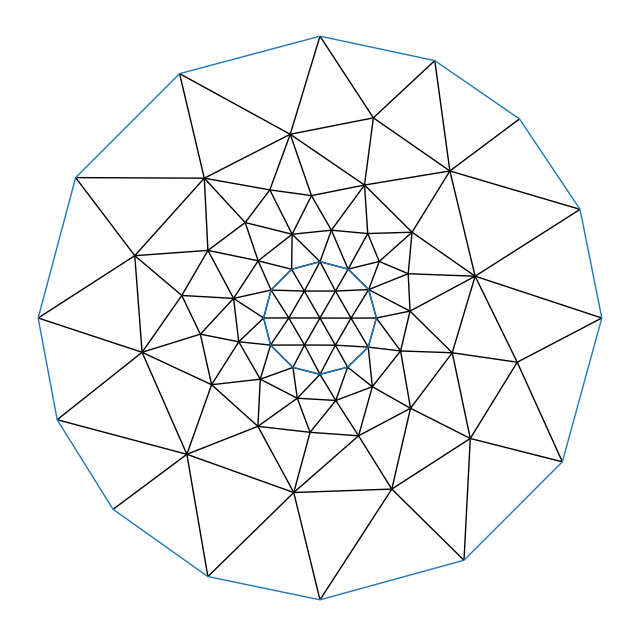

In [7]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

Text(0.5, 1.0, '$n=\\sqrt{\\varepsilon_\\mathrm{r}}$')

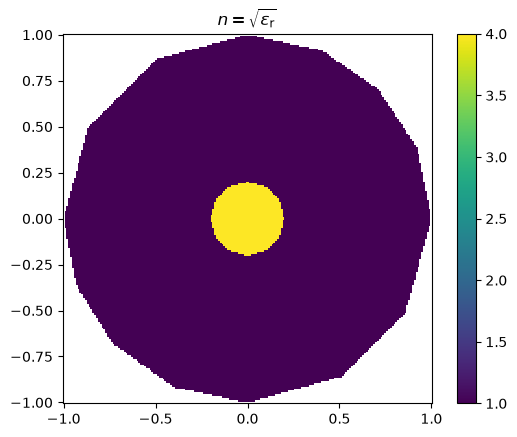

In [8]:
import matplotlib.pyplot as plt
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

Z = refractive_index(X, Y)

plt.pcolormesh(X, Y, Z)
plt.axis('square')
plt.colorbar()
plt.title('$n=\\sqrt{\\varepsilon_\\mathrm{r}}$')

In [9]:
Boundaries = mesh.boundaries
list(Boundaries)

[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

In [10]:
mesh.curve_boundary(Boundaries.SIGMA, radius=R)
#mesh.curve_boundary(Boundaries.D_OMEGA, radius=R)


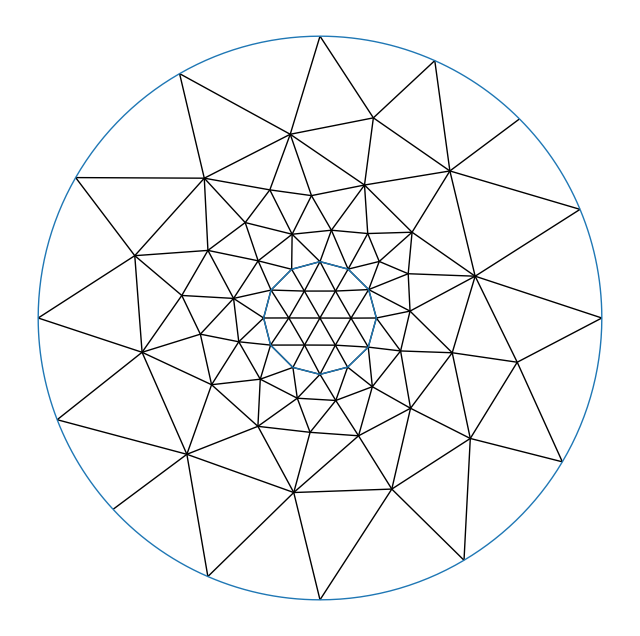

In [11]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [12]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [13]:
import numpy as np
from trefftz.dg.exact import PlaneWave
theta_inc = np.pi
d_inc = np.array([np.cos(theta_inc), np.sin(theta_inc)])
data = PlaneWave(d=d_inc, A=1.)
boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=data), Boundaries.D_OMEGA: DirichletBC(data=None)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [ ]:
from trefftz.dg.block_fluxes import UltraWeakFlux, DirichletFlux

as well as specific ones (for a circular NtD map):

In [15]:
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [32]:
from trefftz.dg.assemblers import BlockNumerics
NtD_modes = 15
a = 0.5
b = 0.5
d2 = 0.5
numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=None), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=data)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = data)})

We should also choose a local basis

In [48]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
Ntheta = 18
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, refractive_index=refractive_index, k=k, N_theta=Ntheta)

and an assembler:

In [49]:
basis.N_DOF

2340

In [50]:
from trefftz.dg.assemblers import BlockAssembler

assembler = BlockAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [51]:
assembler._regions_RHS_term

[<Boundaries.SIGMA: 'Sigma'>]

so we can set the problem:

In [52]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [53]:
A = P.assemble_LHS()

assembling local operators
region: Sigma


100%|██████████| 14/14 [00:00<00:00, 16.14edge/s]


region: d_Omega


Interior: 100%|██████████| 188/188 [00:00<00:00, 1047.64edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 14/14 [01:09<00:00,  4.98s/edge]


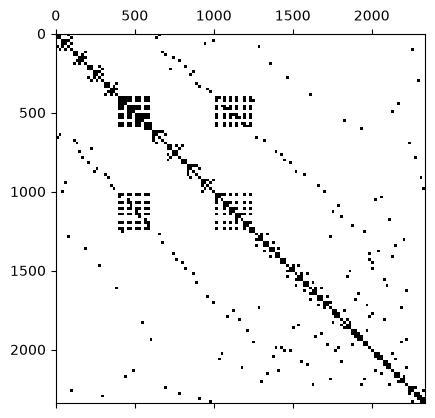

In [54]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [55]:
b = P.assemble_RHS()

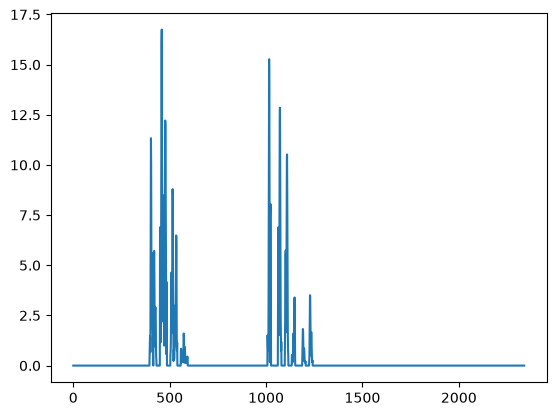

In [56]:
import numpy as np 
plt.plot(np.abs(b))

In [57]:
P.solve()

In [58]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[-3.48643298e+04+3.61234675e+05j,  3.44094268e+05-2.00122356e+05j,
        -4.29270029e+05-1.26972219e+05j, ...,
        -4.14264619e+05+2.51677168e+05j,  4.19217527e+05-3.10399361e+04j,
        -2.81293793e+05-2.39027603e+05j],
       [-2.31501117e+01+8.80212763e+00j,  4.02955500e+00+1.98574242e+01j,
         1.65996502e+01-1.82683030e+00j, ...,
        -2.53385814e+01+2.54753869e+01j,  3.28468076e+01-1.31868652e+00j,
        -1.06527204e+01-2.70974644e+01j],
       [-4.19282630e+04-1.59362087e+05j,  2.12409587e+04+4.51051451e+04j,
        -1.00230463e+05+2.61266881e+04j, ...,
         3.71235264e+05-1.44372548e+05j, -3.51759635e+05-6.65246401e+04j,
         1.95329611e+05+1.97496655e+05j],
       ...,
       [ 3.97157357e-01+2.51594059e+00j, -1.90633585e+00-1.82341129e+00j,
         2.60546034e+00+6.36240198e-01j, ...,
         2.12228392e+00-3.02752424e-01j, -1.93207205e+00+1.22356656e+00j,
         1.00551742e+00-2.13649173e+00j],
       [ 3.55999554e+00+2.44206296e+00j, -4.

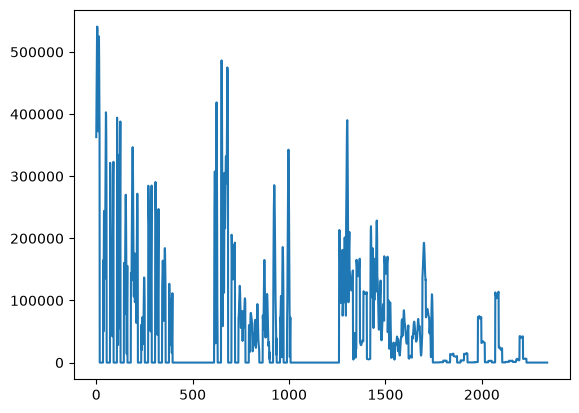

In [59]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

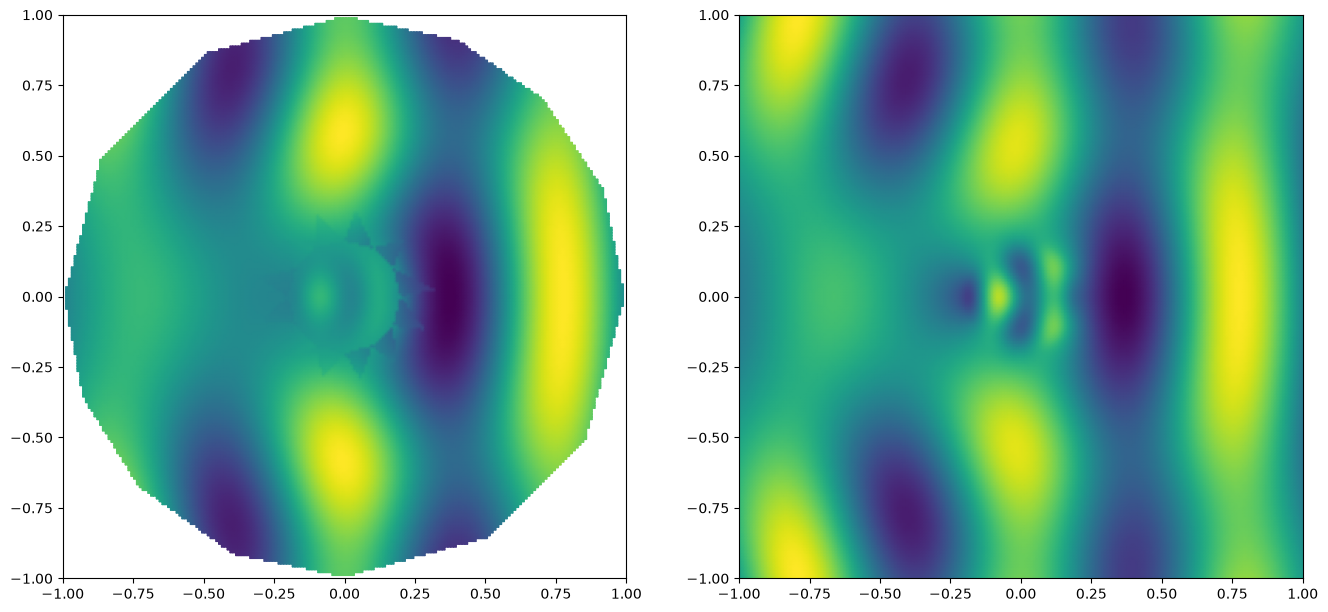

In [60]:
import matplotlib.pyplot as plt
from cases.open_space.exact import nf_diel_cylinder_plane_wave
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

U_h = P.u_h(X, Y)

U_s = nf_diel_cylinder_plane_wave(X, Y, k, theta_inc=np.pi, eps_r=eps_r, c=np.array([0., 0.]), R=r)
U_inc = np.exp(-1j*k*X)

RHO = np.sqrt(X**2 + Y**2)

U = np.where(RHO<r, U_s, U_s+U_inc)

fig, ax = plt.subplots(ncols=2, figsize=(16,8))

ax[0].pcolormesh(X, Y, np.real(U_h), shading="gouraud")
ax[0].axis('square')
ax[1].pcolormesh(X, Y, np.real(U), shading="gouraud")
ax[1].axis('square')


(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

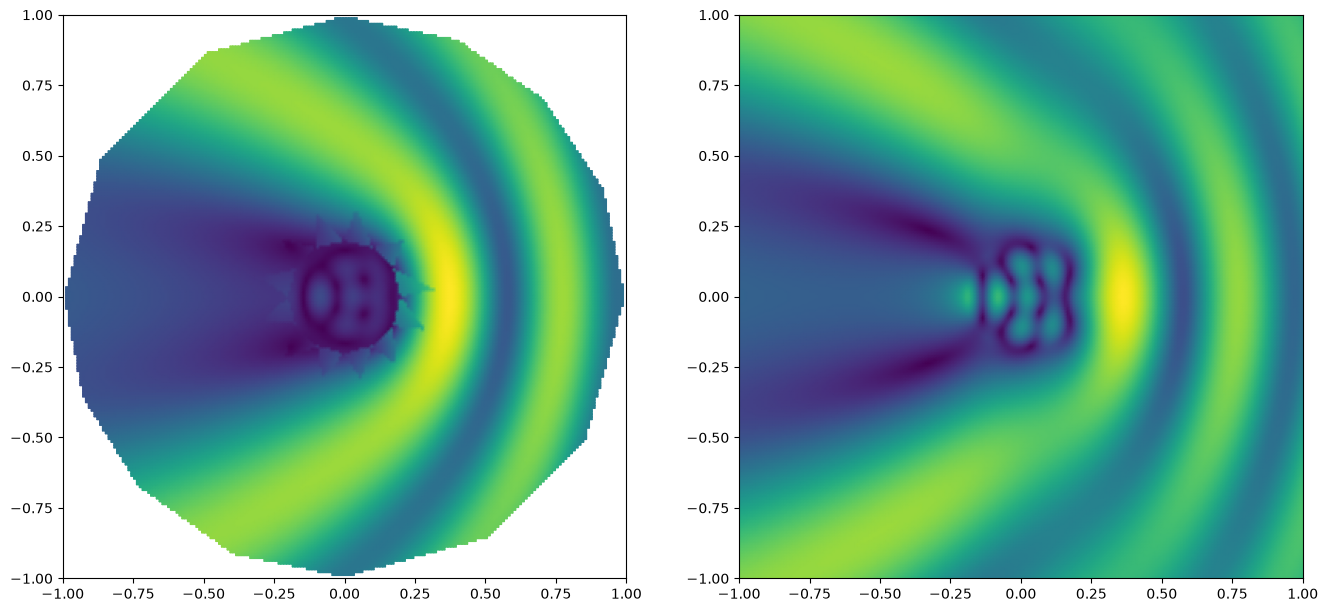

In [61]:
fig, ax = plt.subplots(ncols=2, figsize=(16,8))

ax[0].pcolormesh(X, Y, np.abs(U_h), shading="gouraud")
ax[0].axis('square')
ax[1].pcolormesh(X, Y, np.abs(U), shading="gouraud")
ax[1].axis('square')


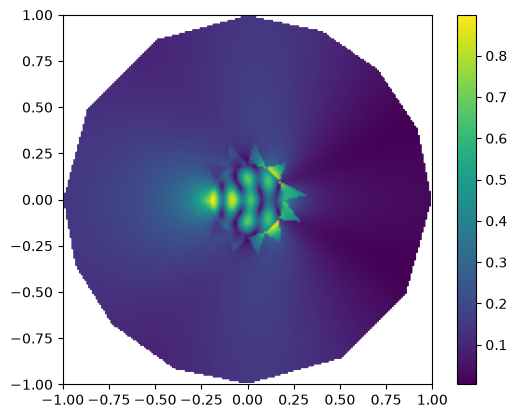

In [62]:
plt.pcolormesh(X, Y, np.abs(U_h - U), shading="gouraud")
plt.axis("square")
plt.colorbar()